In [32]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [ ]:

df = pd.read_csv('air_quality_data_1.csv')  




df  

,Local Time,City,Country code,timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,UTC Time
0,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,2022-12-31T17:00:00
1,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,2022-12-31T18:00:00
2,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,2022-12-31T19:00:00
3,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,2022-12-31T20:00:00
4,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,2022-12-31T21:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
17544,12/31/2024 20:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,1613.0,8.0,2.2,174.0,155.0,32.0,2024-12-31T13:00:00
17545,12/31/2024 21:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,1613.0,8.0,2.2,174.0,155.0,32.0,2024-12-31T14:00:00
17546,12/31/2024 22:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,1613.0,8.0,2.2,174.0,155.0,32.0,2024-12-31T15:00:00
17547,12/31/2024 23:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,264,1214.0,17.7,8.1,153.7,141.0,56.7,2024-12-31T16:00:00


In [ ]:
df.shape

(17549, 12)

In [ ]:
df.describe()

,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2
count,17549,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000,17549.000000
mean,2024-01-01 13:04:44.529033216,121.625620,586.272067,26.041666,53.985384,69.882352,49.363080,66.185048
min,2023-01-01 00:00:00,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000
25%,2023-07-02 19:00:00,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000
50%,2024-01-01 14:00:00,109.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000
75%,2024-07-02 07:00:00,155.000000,571.500000,29.000000,74.000000,80.000000,59.000000,97.000000
max,2025-01-01 00:00:00,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000
std,NaN,61.234654,969.610472,28.066354,44.884866,84.190815,42.344122,49.170026


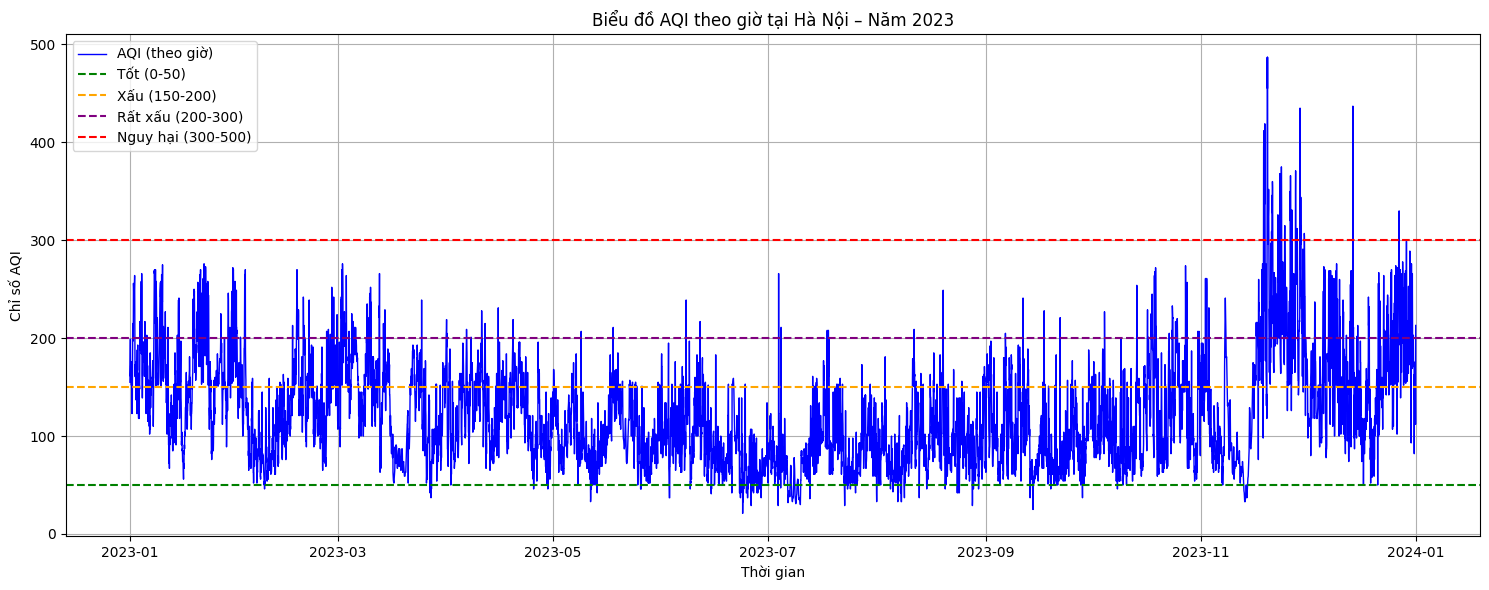

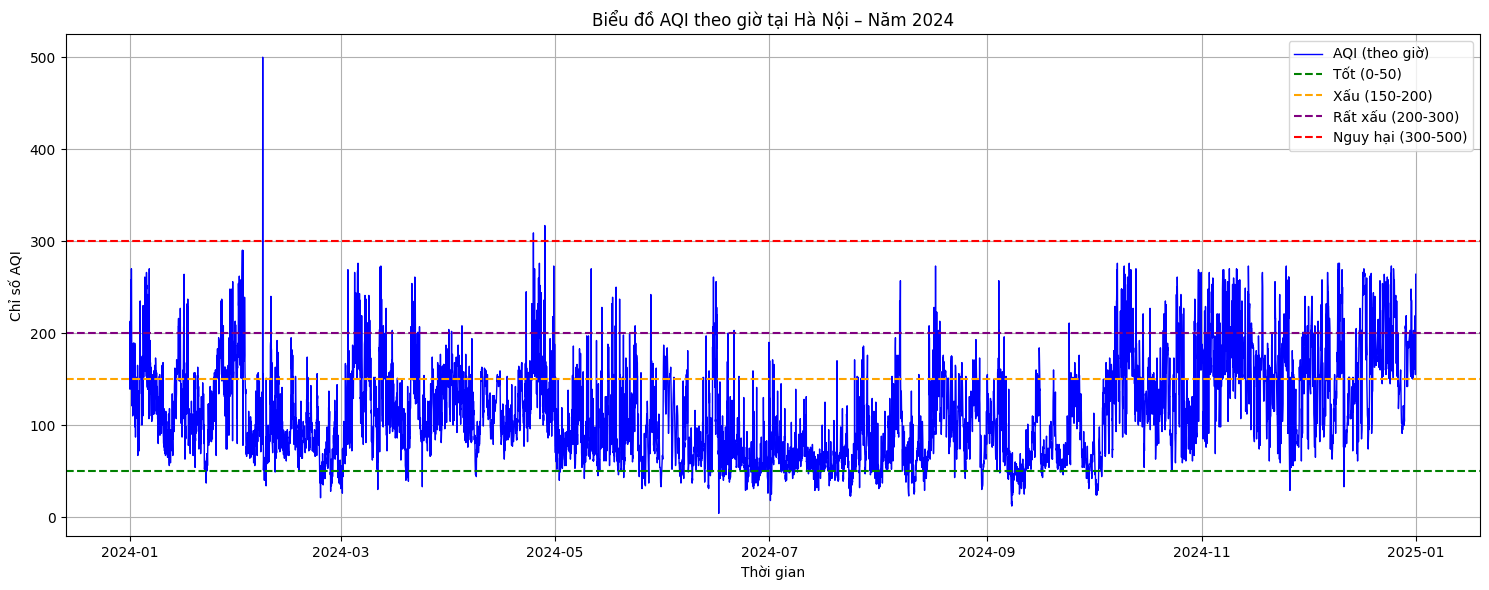

Thời điểm có chỉ số AQI: (9667, np.int64(500))


In [36]:
df['Local Time'] = pd.to_datetime(df['Local Time'])

df_2023 = df[df['Local Time'].dt.year == 2023]
df_2024= df[df['Local Time'].dt.year == 2024]



# Vẽ biểu đồ cho năm 2023
plt.figure(figsize=(15,6))
plt.plot(df_2023['Local Time'], df_2023['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2023')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Vẽ biểu đồ cho năm 2024
plt.figure(figsize=(15,6))
plt.plot(df_2024['Local Time'], df_2024['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2024')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

highest_aqi_time = df['AQI'].idxmax(), df['AQI'].max()
print("Thời điểm có chỉ số AQI:", highest_aqi_time)

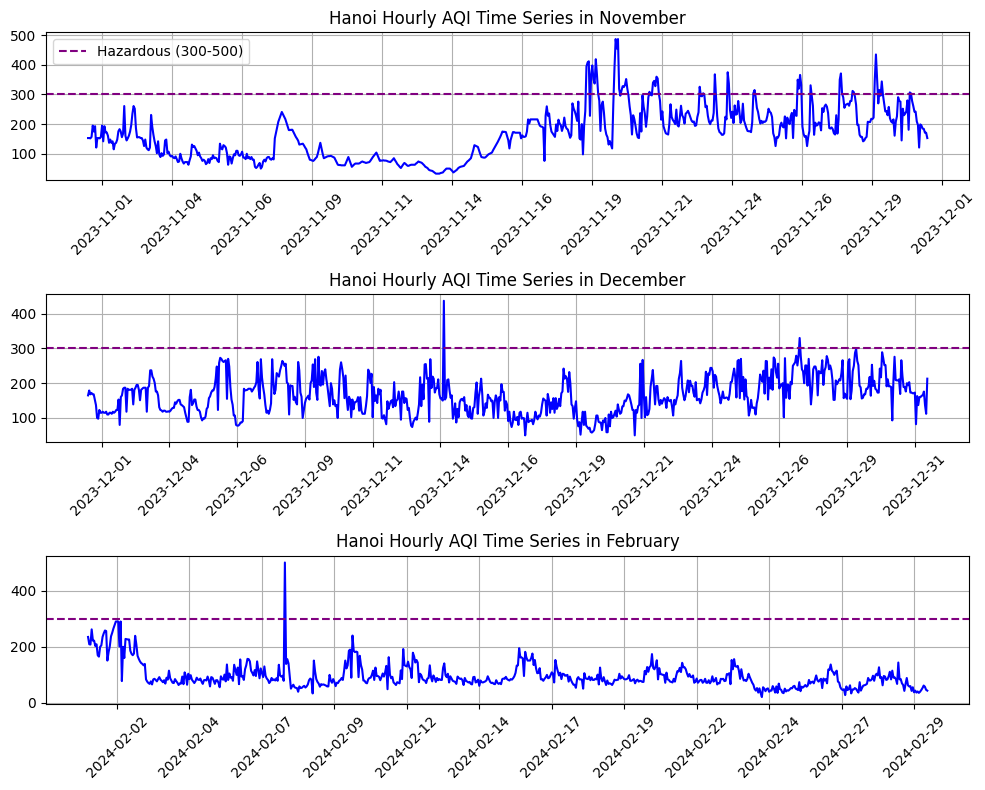

In [37]:
df.set_index('Local Time', inplace=True)
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

# Line Plot November AQI data
axs[0].plot(df['2023-11-01':'2023-11-30']["AQI"], color='b')
axs[0].set_title('Hanoi Hourly AQI Time Series in November')
axs[0].grid(True)
axs[0].axhline(y=300, color='purple', linestyle='--', label='Hazardous (300-500)')
axs[0].legend()

# Line Plot December AQI data
axs[1].plot(df['2023-12-01':'2023-12-31']["AQI"], color='b')
axs[1].set_title('Hanoi Hourly AQI Time Series in December')
axs[1].grid(True)
axs[1].axhline(y=300, color='purple', linestyle='--', label='Hazardous (300-500)')

# Line Plot February AQI data
axs[2].plot(df['2024-02-01':'2024-02-29']["AQI"], color='b')
axs[2].set_title('Hanoi Hourly AQI Time Series in February')
axs[2].grid(True)
axs[2].axhline(y=300, color='purple', linestyle='--', label='Hazardous (300-500)')

# Set x-axis ticks to display only 15 ticks
for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(15))

# Rotate x-axis labels
for ax in axs:
    ax.tick_params(axis='x', rotation=45)

# Show plot
plt.tight_layout()
plt.show()

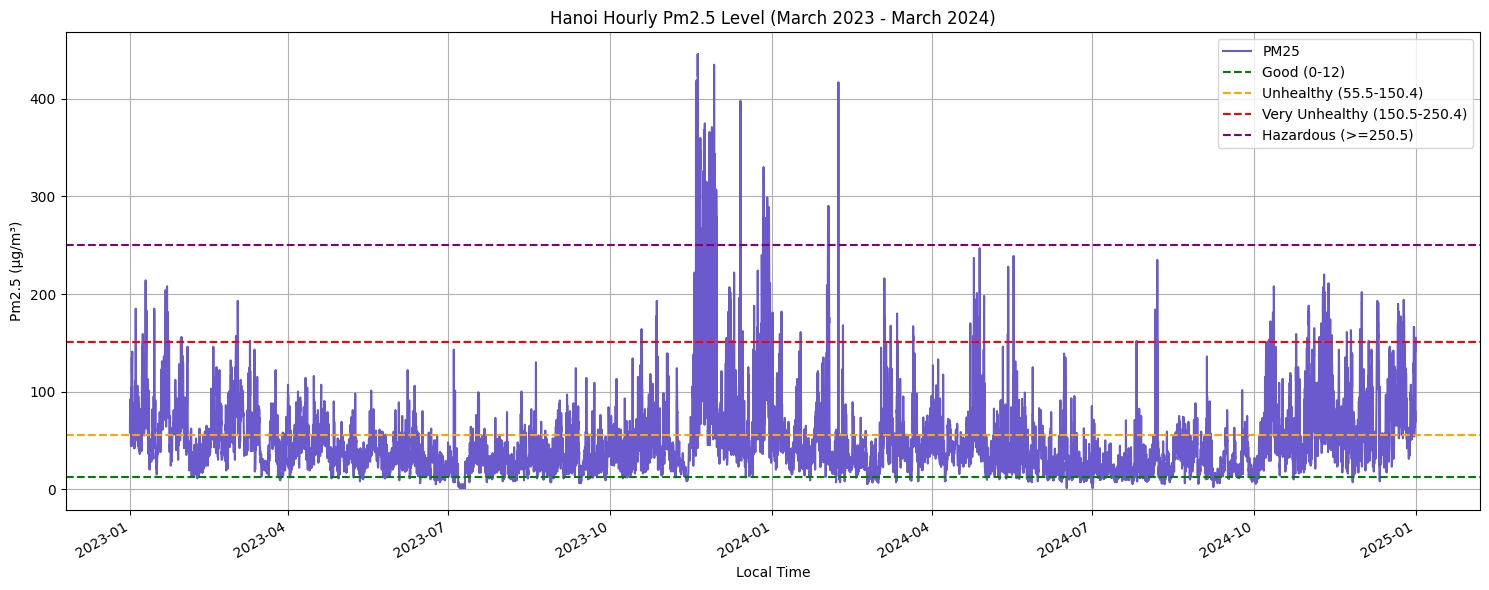

In [38]:
# Plot the AQI time series line plot
plt.figure(figsize=(15, 6))
df['PM25'].plot(kind='line', color='slateblue')

# Add labels and title
plt.xlabel('Local Time')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Hanoi Hourly Pm2.5 Level (March 2023 - March 2024)')
# Add horizontal lines for unhealthy levels
plt.axhline(y=12, color='green', linestyle='--', label='Good (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Unhealthy (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Very Unhealthy (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Hazardous (>=250.5)')
# Show legend
plt.legend()
# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

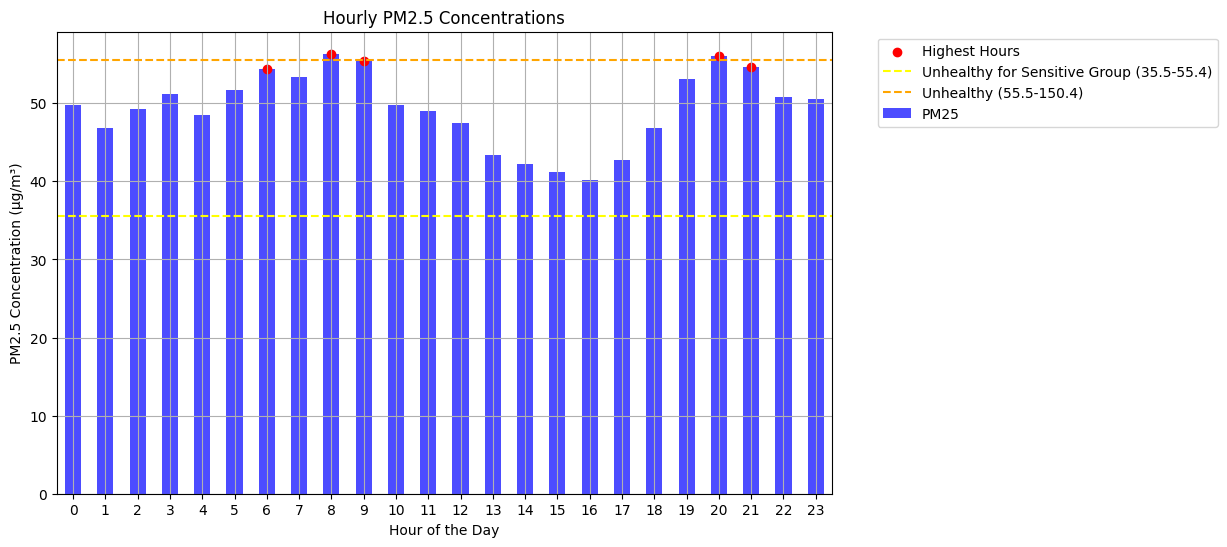

PM2.5 concentration at hour 8: 56.33
PM2.5 concentration at hour 9: 55.45
PM2.5 concentration at hour 19: 53.05
PM2.5 concentration at hour 20: 56.05
PM2.5 concentration at hour 21: 54.67


In [39]:

# Group data by hour and calculate mean PM2.5 concentration for each hour
hourly_pm25 = df['PM25'].groupby(df.index.hour).mean()

# Find hours with highest PM2.5 concentrations
highest_hours = hourly_pm25.nlargest(5)  # Change 5 to the number of highest hours you want to display

# Plot graph
plt.figure(figsize=(10, 6))
hourly_pm25.plot(kind='bar', color='blue', alpha=0.7)  # Plot hourly PM2.5 concentrations
plt.scatter(highest_hours.index, highest_hours.values, color='red', label='Highest Hours')  # Mark highest hours with red dots
plt.title('Hourly PM2.5 Concentrations')
plt.xlabel('Hour of the Day')
plt.ylabel('PM2.5 Concentration (μg/m³)')
plt.axhline(y=35.5, color='yellow', linestyle='--', label='Unhealthy for Sensitive Group (35.5-55.4)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Unhealthy (55.5-150.4)')

# Move the legend to the upper left corner outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)

# Rotate x-axis labels vertically
plt.xticks(rotation='horizontal')

plt.show()

# List of specific hours
specific_hours = [8, 9, 19, 20, 21]

# Print PM2.5 concentrations at specific hours
for hour in specific_hours:
    pm25_concentration = hourly_pm25.loc[hour]
    print(f"PM2.5 concentration at hour {hour}: {pm25_concentration:.2f}")

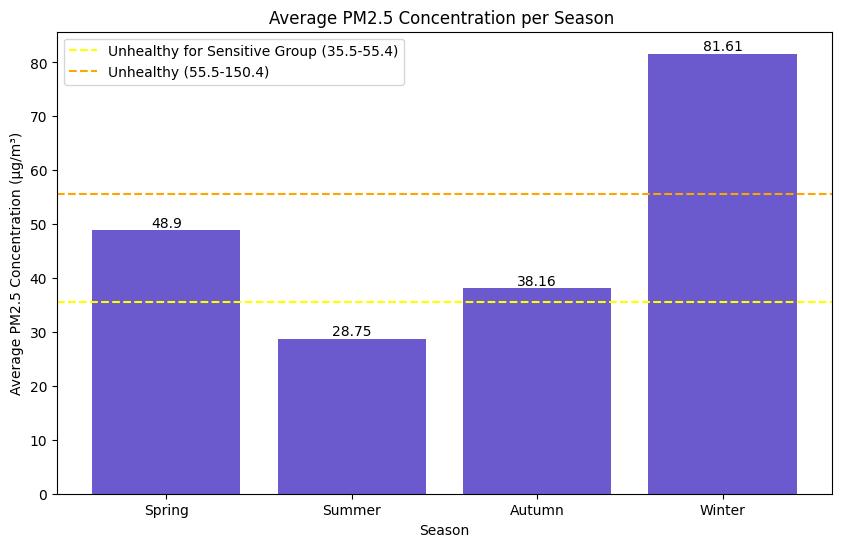

In [40]:
# Define seasons
seasons = {
    'Spring': [2, 3, 4],
    'Summer': [5, 6, 7],
    'Autumn': [8, 9, 10],
    'Winter': [11, 12, 1]
}

# Group data by season and calculate average PM2.5 concentration for each season
seasonal_pm25 = {}
for season, months in seasons.items():
    seasonal_pm25[season] = df.loc[df.index.month.isin(months), 'PM25'].mean()

# Plot the average PM2.5 concentration for each season
plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_pm25.keys(), seasonal_pm25.values(), color='slateblue')
plt.title('Average PM2.5 Concentration per Season ')
plt.xlabel('Season')
plt.ylabel('Average PM2.5 Concentration (μg/m³)')
plt.axhline(y=35.5, color='yellow', linestyle='--', label='Unhealthy for Sensitive Group (35.5-55.4)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Unhealthy (55.5-150.4)')
plt.legend()

# Annotate the bars with the average PM2.5 concentration values for each season
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()